# What Makes a YouTube Video Trend in the US?

EDA on 47K trending US YouTube videos (2020–2024). The dataset contains daily snapshots of the trending page, so the same video can appear multiple times across different dates. After deduplication and cleaning, each video is represented once at its peak view count.

**Dataset:** `US_youtube_trending_data.csv` — 268,787 rows → 47,124 unique videos after cleaning.

**Key questions explored:**
1. What categories dominate trending?
2. What drives engagement?
3. How long do videos stay trending?
4. Does upload timing matter?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

In [2]:
my_csv_path = os.path.join("data", "US_youtube_trending_data.csv")
my_json_path = os.path.join("data", "US_category_id.json")

youtube_csv = pd.read_csv(my_csv_path)

with open(my_json_path) as json_file:
    category_data = json.load(json_file)

In [3]:
youtube_csv.shape

(268787, 16)

In [4]:
youtube_csv.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description
0,3C66w5Z0ixs,I ASKED HER TO BE MY GIRLFRIEND...,2020-08-11T19:20:14Z,UCvtRTOMP2TqYqu51xNrqAzg,Brawadis,22,2020-08-12T00:00:00Z,brawadis|prank|basketball|skits|ghost|funny vi...,1514614,156908,5855,35313,https://i.ytimg.com/vi/3C66w5Z0ixs/default.jpg,False,False,SUBSCRIBE to BRAWADIS ▶ http://bit.ly/Subscrib...
1,M9Pmf9AB4Mo,Apex Legends | Stories from the Outlands – “Th...,2020-08-11T17:00:10Z,UC0ZV6M2THA81QT9hrVWJG3A,Apex Legends,20,2020-08-12T00:00:00Z,Apex Legends|Apex Legends characters|new Apex ...,2381688,146739,2794,16549,https://i.ytimg.com/vi/M9Pmf9AB4Mo/default.jpg,False,False,"While running her own modding shop, Ramya Pare..."
2,J78aPJ3VyNs,I left youtube for a month and THIS is what ha...,2020-08-11T16:34:06Z,UCYzPXprvl5Y-Sf0g4vX-m6g,jacksepticeye,24,2020-08-12T00:00:00Z,jacksepticeye|funny|funny meme|memes|jacksepti...,2038853,353787,2628,40221,https://i.ytimg.com/vi/J78aPJ3VyNs/default.jpg,False,False,I left youtube for a month and this is what ha...
3,kXLn3HkpjaA,XXL 2020 Freshman Class Revealed - Official An...,2020-08-11T16:38:55Z,UCbg_UMjlHJg_19SZckaKajg,XXL,10,2020-08-12T00:00:00Z,xxl freshman|xxl freshmen|2020 xxl freshman|20...,496771,23251,1856,7647,https://i.ytimg.com/vi/kXLn3HkpjaA/default.jpg,False,False,Subscribe to XXL → http://bit.ly/subscribe-xxl...
4,VIUo6yapDbc,Ultimate DIY Home Movie Theater for The LaBran...,2020-08-11T15:10:05Z,UCDVPcEbVLQgLZX0Rt6jo34A,Mr. Kate,26,2020-08-12T00:00:00Z,The LaBrant Family|DIY|Interior Design|Makeove...,1123889,45802,964,2196,https://i.ytimg.com/vi/VIUo6yapDbc/default.jpg,False,False,Transforming The LaBrant Family's empty white ...


In [5]:
youtube_csv.columns

Index(['video_id', 'title', 'publishedAt', 'channelId', 'channelTitle',
       'categoryId', 'trending_date', 'tags', 'view_count', 'likes',
       'dislikes', 'comment_count', 'thumbnail_link', 'comments_disabled',
       'ratings_disabled', 'description'],
      dtype='str')

In [ ]:
youtube_csv.describe().style.format('{:,.0f}')

In [7]:
youtube_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 268787 entries, 0 to 268786
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   video_id           268787 non-null  str  
 1   title              268787 non-null  str  
 2   publishedAt        268787 non-null  str  
 3   channelId          268787 non-null  str  
 4   channelTitle       268787 non-null  str  
 5   categoryId         268787 non-null  int64
 6   trending_date      268787 non-null  str  
 7   tags               268787 non-null  str  
 8   view_count         268787 non-null  int64
 9   likes              268787 non-null  int64
 10  dislikes           268787 non-null  int64
 11  comment_count      268787 non-null  int64
 12  thumbnail_link     268787 non-null  str  
 13  comments_disabled  268787 non-null  bool 
 14  ratings_disabled   268787 non-null  bool 
 15  description        264238 non-null  str  
dtypes: bool(2), int64(5), str(9)
memory usage: 399.6 

In [8]:
category_data

{'kind': 'youtube#videoCategoryListResponse',
 'etag': 'HIrK3n45Uw2IYz9_U2-gK1OsXvo',
 'items': [{'kind': 'youtube#videoCategory',
   'etag': 'IfWa37JGcqZs-jZeAyFGkbeh6bc',
   'id': '1',
   'snippet': {'title': 'Film & Animation',
    'assignable': True,
    'channelId': 'UCBR8-60-B28hp2BmDPdntcQ'}},
  {'kind': 'youtube#videoCategory',
   'etag': '5XGylIs7zkjHh5940dsT5862m1Y',
   'id': '2',
   'snippet': {'title': 'Autos & Vehicles',
    'assignable': True,
    'channelId': 'UCBR8-60-B28hp2BmDPdntcQ'}},
  {'kind': 'youtube#videoCategory',
   'etag': 'HCjFMARbBeWjpm6PDfReCOMOZGA',
   'id': '10',
   'snippet': {'title': 'Music',
    'assignable': True,
    'channelId': 'UCBR8-60-B28hp2BmDPdntcQ'}},
  {'kind': 'youtube#videoCategory',
   'etag': 'ra8H7xyAfmE2FewsDabE3TUSq10',
   'id': '15',
   'snippet': {'title': 'Pets & Animals',
    'assignable': True,
    'channelId': 'UCBR8-60-B28hp2BmDPdntcQ'}},
  {'kind': 'youtube#videoCategory',
   'etag': '7mqChSJogdF3hSIL-88BfDE-W8M',
   'id': '

In [9]:
category_map = {item['id']: item['snippet']['title']
                for item in category_data['items']}
category_map

{'1': 'Film & Animation',
 '2': 'Autos & Vehicles',
 '10': 'Music',
 '15': 'Pets & Animals',
 '17': 'Sports',
 '18': 'Short Movies',
 '19': 'Travel & Events',
 '20': 'Gaming',
 '21': 'Videoblogging',
 '22': 'People & Blogs',
 '23': 'Comedy',
 '24': 'Entertainment',
 '25': 'News & Politics',
 '26': 'Howto & Style',
 '27': 'Education',
 '28': 'Science & Technology',
 '29': 'Nonprofits & Activism',
 '30': 'Movies',
 '31': 'Anime/Animation',
 '32': 'Action/Adventure',
 '33': 'Classics',
 '34': 'Comedy',
 '35': 'Documentary',
 '36': 'Drama',
 '37': 'Family',
 '38': 'Foreign',
 '39': 'Horror',
 '40': 'Sci-Fi/Fantasy',
 '41': 'Thriller',
 '42': 'Shorts',
 '43': 'Shows',
 '44': 'Trailers'}

In [10]:
category_df = pd.DataFrame(
    [(int(k), v) for k, v in category_map.items()],
    columns=['categoryId', 'category_name']
)

youtube_df = youtube_csv.merge(category_df, on='categoryId', how='left')
youtube_df.head()

,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,category_name
0,3C66w5Z0ixs,I ASKED HER TO BE MY GIRLFRIEND...,2020-08-11T19:20:14Z,UCvtRTOMP2TqYqu51xNrqAzg,Brawadis,22,2020-08-12T00:00:00Z,brawadis|prank|basketball|skits|ghost|funny vi...,1514614,156908,5855,35313,https://i.ytimg.com/vi/3C66w5Z0ixs/default.jpg,False,False,SUBSCRIBE to BRAWADIS ▶ http://bit.ly/Subscrib...,People & Blogs
1,M9Pmf9AB4Mo,Apex Legends | Stories from the Outlands – “Th...,2020-08-11T17:00:10Z,UC0ZV6M2THA81QT9hrVWJG3A,Apex Legends,20,2020-08-12T00:00:00Z,Apex Legends|Apex Legends characters|new Apex ...,2381688,146739,2794,16549,https://i.ytimg.com/vi/M9Pmf9AB4Mo/default.jpg,False,False,"While running her own modding shop, Ramya Pare...",Gaming
2,J78aPJ3VyNs,I left youtube for a month and THIS is what ha...,2020-08-11T16:34:06Z,UCYzPXprvl5Y-Sf0g4vX-m6g,jacksepticeye,24,2020-08-12T00:00:00Z,jacksepticeye|funny|funny meme|memes|jacksepti...,2038853,353787,2628,40221,https://i.ytimg.com/vi/J78aPJ3VyNs/default.jpg,False,False,I left youtube for a month and this is what ha...,Entertainment
3,kXLn3HkpjaA,XXL 2020 Freshman Class Revealed - Official An...,2020-08-11T16:38:55Z,UCbg_UMjlHJg_19SZckaKajg,XXL,10,2020-08-12T00:00:00Z,xxl freshman|xxl freshmen|2020 xxl freshman|20...,496771,23251,1856,7647,https://i.ytimg.com/vi/kXLn3HkpjaA/default.jpg,False,False,Subscribe to XXL → http://bit.ly/subscribe-xxl...,Music
4,VIUo6yapDbc,Ultimate DIY Home Movie Theater for The LaBran...,2020-08-11T15:10:05Z,UCDVPcEbVLQgLZX0Rt6jo34A,Mr. Kate,26,2020-08-12T00:00:00Z,The LaBrant Family|DIY|Interior Design|Makeove...,1123889,45802,964,2196,https://i.ytimg.com/vi/VIUo6yapDbc/default.jpg,False,False,Transforming The LaBrant Family's empty white ...,Howto & Style


In [11]:
youtube_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 268787 entries, 0 to 268786
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   video_id           268787 non-null  str  
 1   title              268787 non-null  str  
 2   publishedAt        268787 non-null  str  
 3   channelId          268787 non-null  str  
 4   channelTitle       268787 non-null  str  
 5   categoryId         268787 non-null  int64
 6   trending_date      268787 non-null  str  
 7   tags               268787 non-null  str  
 8   view_count         268787 non-null  int64
 9   likes              268787 non-null  int64
 10  dislikes           268787 non-null  int64
 11  comment_count      268787 non-null  int64
 12  thumbnail_link     268787 non-null  str  
 13  comments_disabled  268787 non-null  bool 
 14  ratings_disabled   268787 non-null  bool 
 15  description        264238 non-null  str  
 16  category_name      268787 non-null  str  
dtypes:

In [12]:
youtube_df['has_description'] = youtube_df['description'].notna()
youtube_df['description_length'] = youtube_df['description'].str.len().fillna(
    0).astype(int)

youtube_df[['description', 'has_description', 'description_length']].head(10)

,description,has_description,description_length
0,SUBSCRIBE to BRAWADIS ▶ http://bit.ly/Subscrib...,True,361
1,"While running her own modding shop, Ramya Pare...",True,715
2,I left youtube for a month and this is what ha...,True,513
3,Subscribe to XXL → http://bit.ly/subscribe-xxl...,True,762
4,Transforming The LaBrant Family's empty white ...,True,2493
5,Subscribe To My Channel - https://www.youtube....,True,1389
6,Hi babygirls! Thank you so much for watching ...,True,578
7,‣ What Was TEKOI: https://www.youtube.com/watc...,True,1236
8,"Since I was little, i've had these goals for m...",True,1063
9,Vengo De Nada - Ovi x Natanael Cano x Aleman x...,True,1267


In [13]:
trending_days = youtube_df.groupby('video_id')['trending_date'].nunique()
youtube_df['trending_days'] = youtube_df['video_id'].map(trending_days)

youtube_df[['video_id', 'trending_days']].head(10)

,video_id,trending_days
0,3C66w5Z0ixs,7
1,M9Pmf9AB4Mo,5
2,J78aPJ3VyNs,7
3,kXLn3HkpjaA,5
4,VIUo6yapDbc,6
5,w-aidBdvZo8,6
6,uet14uf9NsE,6
7,ua4QMFQATco,6
8,SnsPZj91R7E,6
9,SsWHMAhshPQ,6


## 1. Data Cleaning

The raw data has 268,787 rows because a single video appears once per trending day. I kept one row per video at its peak view count, then converted date columns, added time and engagement features, and fixed three data quality issues: negative `days_to_trend` from UTC offset artifacts, 18 rows with zero views, and tags stored as the literal string `'[None]'`.

In [14]:
before = len(youtube_df)

youtube_df = (youtube_df
              .sort_values('view_count', ascending=False)
              .drop_duplicates(subset='video_id', keep='first')
              .reset_index(drop=True))

after = len(youtube_df)
print(f"Before: {before:,} rows")
print(f"After:  {after:,} rows ({before - after:,} duplicates removed)")

Before: 268,787 rows
After:  47,142 rows (221,645 duplicates removed)


In [15]:
print(f"Duplicate video_ids remaining: {youtube_df['video_id'].duplicated().sum()}")
print(f"Final shape: {youtube_df.shape}")
youtube_df.head(3)

Duplicate video_ids remaining: 0
Final shape: (47142, 20)


,video_id,title,publishedAt,channelId,channelTitle,categoryId,trending_date,tags,view_count,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,description,category_name,has_description,description_length,trending_days
0,cc2-4ci4G84,Discord Loot Boxes are here.,2024-04-01T17:46:17Z,UCZ5XnGb-3t7jCkXdawN2tkA,Discord,24,2024-04-03T00:00:00Z,[None],1407643634,126926,0,13987,https://i.ytimg.com/vi/cc2-4ci4G84/default.jpg,False,False,Why would we ever bring Loot Boxes into a chat...,Entertainment,True,100,11
1,gQlMMD8auMs,BLACKPINK - ‘Pink Venom’ M/V,2022-08-19T04:00:13Z,UCOmHUn--16B90oW2L6FRR3A,BLACKPINK,10,2022-09-10T00:00:00Z,YG Entertainment|YG|와이지|K-pop|BLACKPINK|블랙핑크|블...,277791741,12993894,0,3534337,https://i.ytimg.com/vi/gQlMMD8auMs/default.jpg,False,False,BLACKPINK - ‘Pink Venom’ M/VKick in the door W...,Music,True,2279,23
2,WMweEpGlu_U,BTS (방탄소년단) 'Butter' Official MV,2021-05-21T03:46:13Z,UC3IZKseVpdzPSBaWxBxundA,HYBE LABELS,10,2021-05-30T00:00:00Z,BIGHIT|빅히트|방탄소년단|BTS|BANGTAN|방탄,264407389,16021534,150989,6738537,https://i.ytimg.com/vi/WMweEpGlu_U/default.jpg,False,False,BTS (방탄소년단) 'Butter' Official MV Credits: Dire...,Music,True,2264,4


In [16]:
youtube_df['publishedAt'] = pd.to_datetime(youtube_df['publishedAt'], utc=True)
youtube_df['trending_date'] = pd.to_datetime(youtube_df['trending_date'], utc=True)

youtube_df[['publishedAt', 'trending_date']].dtypes

publishedAt      datetime64[us, UTC]
trending_date    datetime64[us, UTC]
dtype: object

In [17]:
youtube_df['publish_hour'] = youtube_df['publishedAt'].dt.hour
youtube_df['publish_dayofweek'] = youtube_df['publishedAt'].dt.dayofweek
youtube_df['days_to_trend'] = (youtube_df['trending_date'] - youtube_df['publishedAt']).dt.days
youtube_df['engagement_rate'] = youtube_df['likes'] / youtube_df['view_count'].replace(0, np.nan)

youtube_df = youtube_df.drop(columns=['dislikes'])

youtube_df[['publish_hour', 'publish_dayofweek', 'days_to_trend', 'engagement_rate']].describe()

,publish_hour,publish_dayofweek,days_to_trend,engagement_rate
count,47142,47142,47142,47124
mean,14,3,5,0
std,7,2,2,0
min,0,0,-1,0
25%,10,1,4,0
50%,16,3,5,0
75%,19,5,6,0
max,23,6,36,0


In [18]:
youtube_df['days_to_trend'] = youtube_df['days_to_trend'].clip(lower=0)

youtube_df = youtube_df[youtube_df['view_count'] > 0].reset_index(drop=True)

youtube_df['tags'] = youtube_df['tags'].replace('[None]', np.nan)

print(f"Rows after cleaning: {len(youtube_df):,}")
print(f"days_to_trend < 0: {(youtube_df['days_to_trend'] < 0).sum()}")
print(f"view_count == 0: {(youtube_df['view_count'] == 0).sum()}")
print(f"tags null: {youtube_df['tags'].isnull().sum():,}")

Rows after cleaning: 47,124
days_to_trend < 0: 0
view_count == 0: 0
tags null: 7,764


## 2. What Categories Dominate Trending?

Gaming and Entertainment take up the most spots on the trending page, but Music punches well above its weight in average views — 4.9M per video compared to Gaming's 1.7M. Volume and reach don't always go hand in hand.

In [19]:
category_stats = (youtube_df.groupby('category_name')
                  .agg(video_count=('video_id', 'count'),
                       avg_views=('view_count', 'mean'),
                       avg_likes=('likes', 'mean'),
                       avg_engagement=('engagement_rate', 'mean'))
                  .sort_values('video_count', ascending=False)
                  .reset_index())

category_stats

,category_name,video_count,avg_views,avg_likes,avg_engagement
0,Gaming,9434,1744901,84722,0
1,Entertainment,9183,3591306,144086,0
2,Music,7347,4918399,265921,0
3,Sports,6073,1668339,35231,0
4,People & Blogs,4032,1975978,102641,0
5,Comedy,2254,1743881,118109,0
6,Film & Animation,1831,3091918,108842,0
7,News & Politics,1732,1444337,19443,0
8,Science & Technology,1424,2974000,103683,0
9,Howto & Style,1216,1510762,71212,0


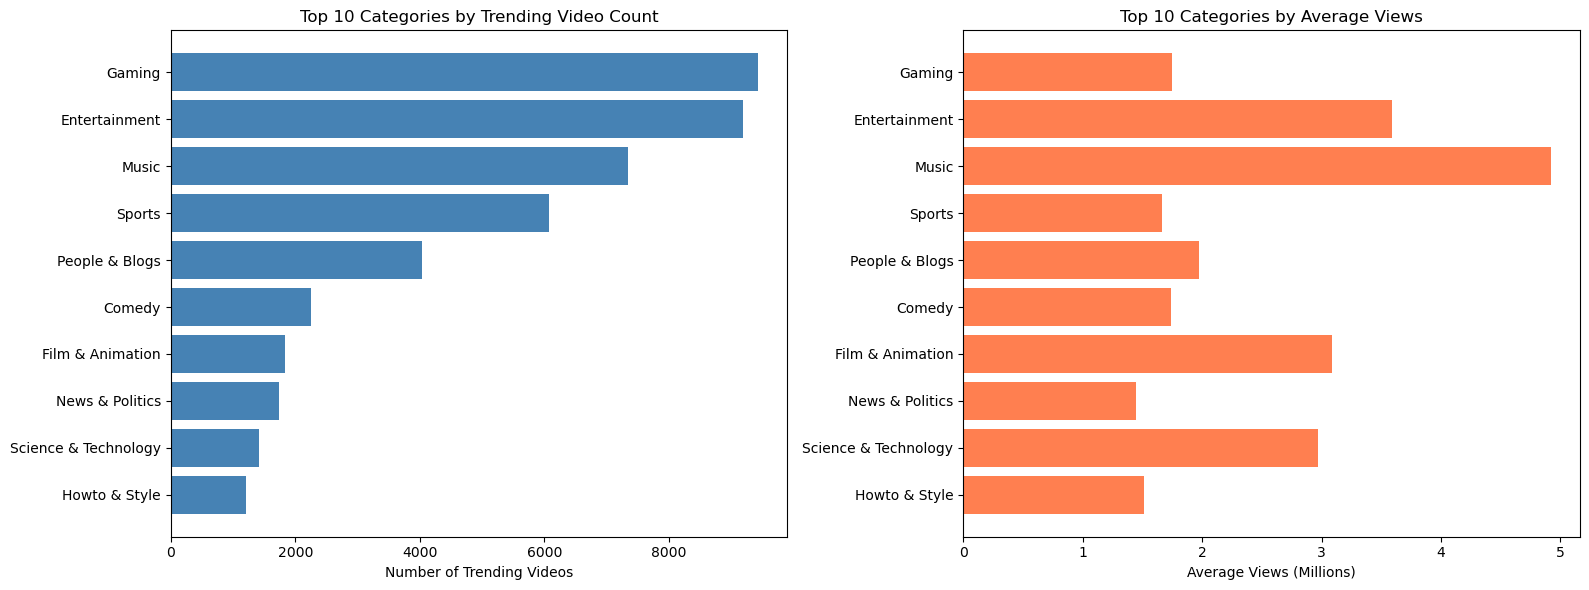

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_cats = category_stats.head(10)

axes[0].barh(top_cats['category_name'][::-1], top_cats['video_count'][::-1], color='steelblue')
axes[0].set_xlabel('Number of Trending Videos')
axes[0].set_title('Top 10 Categories by Trending Video Count')

axes[1].barh(top_cats['category_name'][::-1], top_cats['avg_views'][::-1] / 1e6, color='coral')
axes[1].set_xlabel('Average Views (Millions)')
axes[1].set_title('Top 10 Categories by Average Views')

plt.tight_layout()
plt.show()

## 3. What Drives Engagement?

Engagement rate is defined as likes divided by views. Comedy leads at 7.1%, which is notable because it has far fewer trending videos than Gaming or Entertainment. The scatter plot shows that engagement doesn't keep climbing with views — past a few million, the rate flattens out quickly.

In [21]:
engagement_by_cat = (youtube_df.groupby('category_name')['engagement_rate']
                     .median()
                     .sort_values(ascending=False)
                     .reset_index())
engagement_by_cat.columns = ['category_name', 'median_engagement_rate']

engagement_by_cat

,category_name,median_engagement_rate
0,Comedy,0
1,Nonprofits & Activism,0
2,People & Blogs,0
3,Howto & Style,0
4,Music,0
5,Education,0
6,Film & Animation,0
7,Gaming,0
8,Travel & Events,0
9,Autos & Vehicles,0


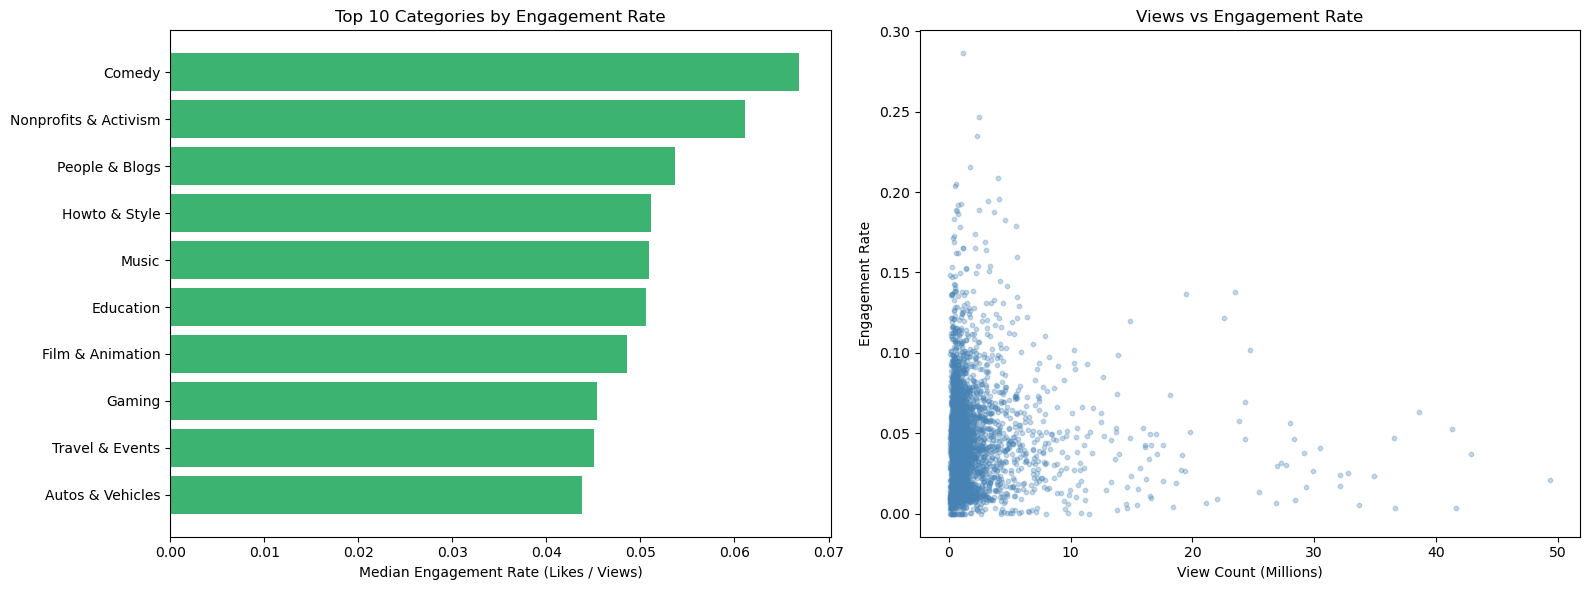

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_eng = engagement_by_cat.head(10)
axes[0].barh(top_eng['category_name'][::-1], top_eng['median_engagement_rate'][::-1], color='mediumseagreen')
axes[0].set_xlabel('Median Engagement Rate (Likes / Views)')
axes[0].set_title('Top 10 Categories by Engagement Rate')

sample = youtube_df[youtube_df['view_count'] < 5e7].sample(3000, random_state=42)
axes[1].scatter(sample['view_count'] / 1e6, sample['engagement_rate'], alpha=0.3, s=10, color='steelblue')
axes[1].set_xlabel('View Count (Millions)')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_title('Views vs Engagement Rate')

plt.tight_layout()
plt.show()

## 4. How Long Do Videos Stay Trending?

The median video stays on trending for 6 days, and most fall between 4 and 8. The boxplot tells a more interesting story than the median — Music and Entertainment have wider spreads, meaning a small number of breakout videos can stay trending for weeks while the rest fade quickly.

In [23]:
trending_days_by_cat = (youtube_df.groupby('category_name')['trending_days']
                        .median()
                        .sort_values(ascending=False)
                        .reset_index())
trending_days_by_cat.columns = ['category_name', 'median_trending_days']

trending_days_by_cat

,category_name,median_trending_days
0,Autos & Vehicles,6
1,Comedy,6
2,Education,6
3,Entertainment,6
4,Film & Animation,6
5,Howto & Style,6
6,Music,6
7,Pets & Animals,6
8,Science & Technology,6
9,Travel & Events,6


/var/folders/hv/lgz_pfq5065gd_rwy3xs1ccw0000gn/T/ipykernel_60923/1177438811.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_cat, labels=cat_order, vert=False, patch_artist=True,


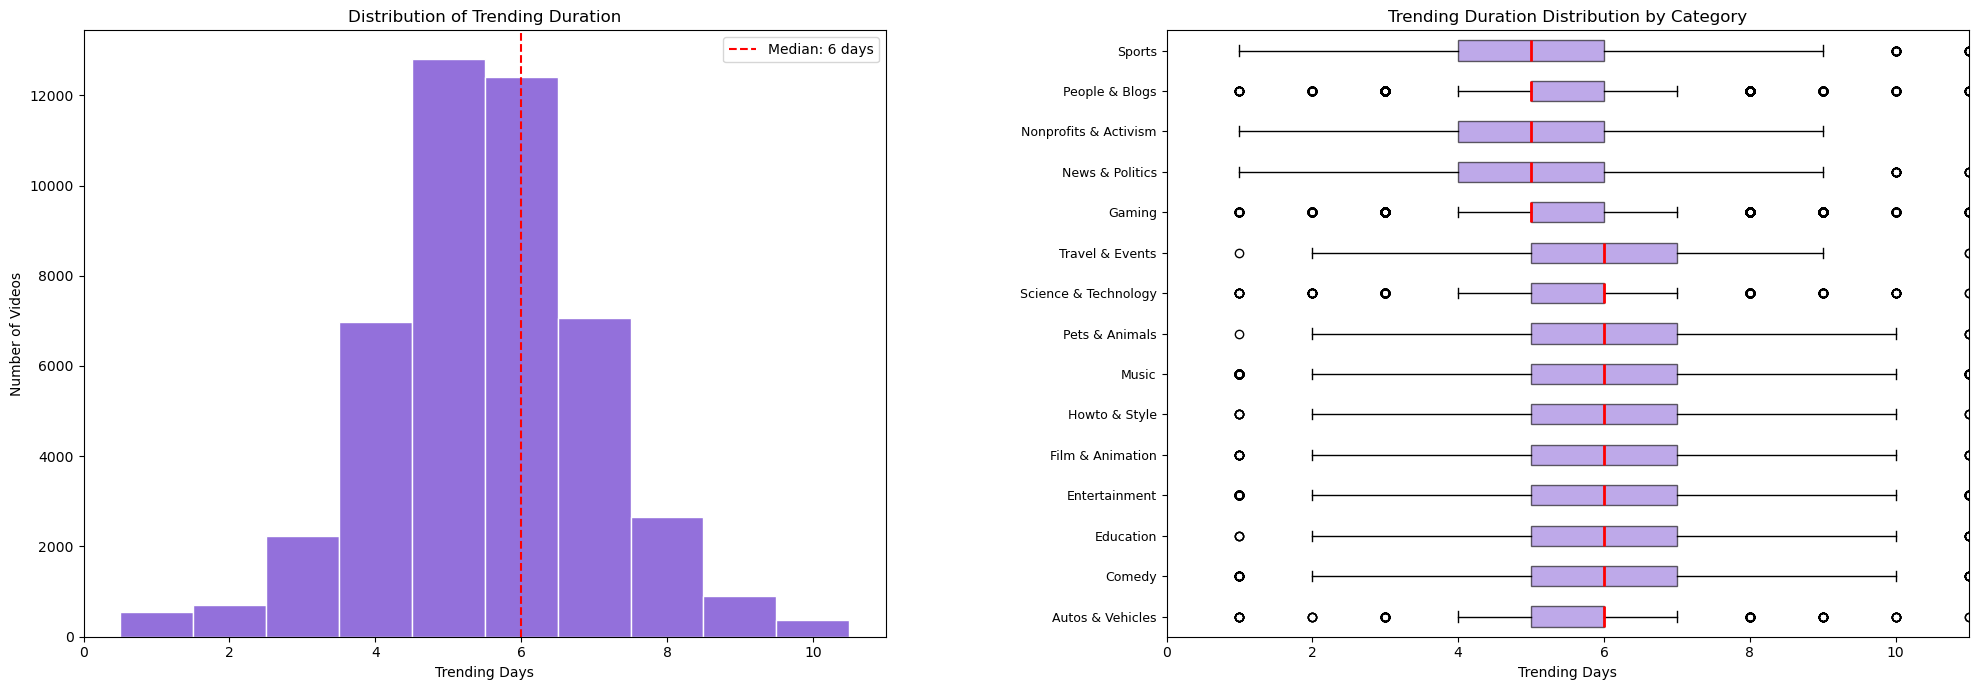

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

cap = int(youtube_df['trending_days'].quantile(0.99))
clipped = youtube_df[youtube_df['trending_days'] <= cap]['trending_days']

axes[0].hist(clipped, bins=range(1, cap + 2), color='mediumpurple', edgecolor='white', align='left')
axes[0].axvline(clipped.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median: {clipped.median():.0f} days')
axes[0].set_xlabel('Trending Days')
axes[0].set_ylabel('Number of Videos')
axes[0].set_title('Distribution of Trending Duration')
axes[0].legend()

cat_order = (youtube_df.groupby('category_name')['trending_days']
             .median()
             .sort_values(ascending=False)
             .index.tolist())
data_by_cat = [youtube_df[youtube_df['category_name'] == cat]['trending_days'].dropna().values
               for cat in cat_order]

axes[1].boxplot(data_by_cat, labels=cat_order, vert=False, patch_artist=True,
                boxprops=dict(facecolor='mediumpurple', alpha=0.6),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_xlabel('Trending Days')
axes[1].set_title('Trending Duration Distribution by Category')
axes[1].set_xlim(0, cap + 1)
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.subplots_adjust(left=0.05, wspace=0.35)
plt.show()

## 5. Does Timing Matter?

Videos uploaded between 3–5 PM UTC (10 AM–12 PM ET) appear most often in trending, with Fridays and Tuesdays being the most common upload days. That said, average views stay fairly flat across hours and days — timing affects how many videos get uploaded into trending, but not necessarily how well they perform once there.

In [25]:
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

hour_stats = (youtube_df.groupby('publish_hour')
              .agg(video_count=('video_id', 'count'),
                   avg_views=('view_count', 'mean'))
              .reset_index())

dow_stats = (youtube_df.groupby('publish_dayofweek')
             .agg(video_count=('video_id', 'count'),
                  avg_views=('view_count', 'mean'))
             .reset_index())
dow_stats['day_label'] = dow_stats['publish_dayofweek'].map(lambda x: day_labels[x])

print("Upload hour stats (top 5 by video count):")
print(hour_stats.nlargest(5, 'video_count').to_string(index=False))
print("\nUpload day stats:")
print(dow_stats[['day_label', 'video_count', 'avg_views']].to_string(index=False))

Upload hour stats (top 5 by video count):
 publish_hour  video_count  avg_views
           16         4299    2401107
           17         4005    2700239
           15         3761    2661316
           18         3052    2125007
           19         3008    2187591

Upload day stats:
day_label  video_count  avg_views
      Mon         6801    2759482
      Tue         7037    2332074
      Wed         6883    2315662
      Thu         6420    2538083
      Fri         7669    3524738
      Sat         5829    3051203
      Sun         6485    2100116


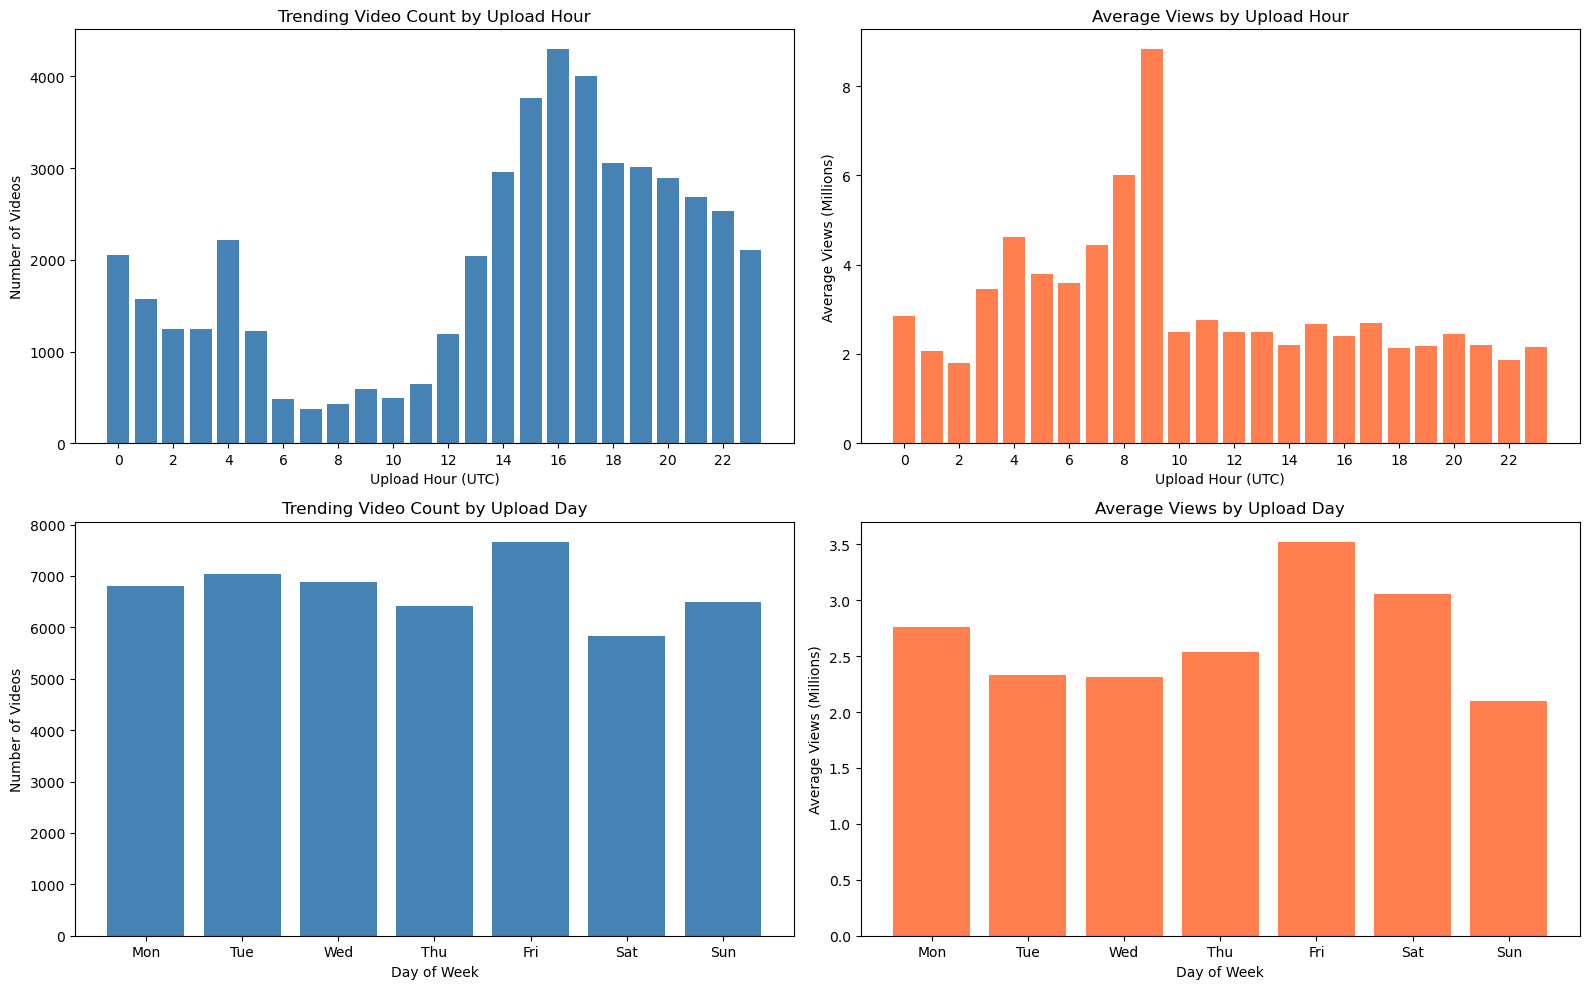

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].bar(hour_stats['publish_hour'], hour_stats['video_count'], color='steelblue')
axes[0, 0].set_xlabel('Upload Hour (UTC)')
axes[0, 0].set_ylabel('Number of Videos')
axes[0, 0].set_title('Trending Video Count by Upload Hour')
axes[0, 0].set_xticks(range(0, 24, 2))

axes[0, 1].bar(hour_stats['publish_hour'], hour_stats['avg_views'] / 1e6, color='coral')
axes[0, 1].set_xlabel('Upload Hour (UTC)')
axes[0, 1].set_ylabel('Average Views (Millions)')
axes[0, 1].set_title('Average Views by Upload Hour')
axes[0, 1].set_xticks(range(0, 24, 2))

axes[1, 0].bar(dow_stats['day_label'], dow_stats['video_count'], color='steelblue')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Number of Videos')
axes[1, 0].set_title('Trending Video Count by Upload Day')

axes[1, 1].bar(dow_stats['day_label'], dow_stats['avg_views'] / 1e6, color='coral')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Average Views (Millions)')
axes[1, 1].set_title('Average Views by Upload Day')

plt.tight_layout()
plt.show()

## Putting It Together: Category Landscape

The bubble chart below plots each category by average views (reach) vs. average engagement rate, with bubble size representing median trending duration. This gives a clearer picture of where each category sits — high reach but low engagement, or niche but interactive.

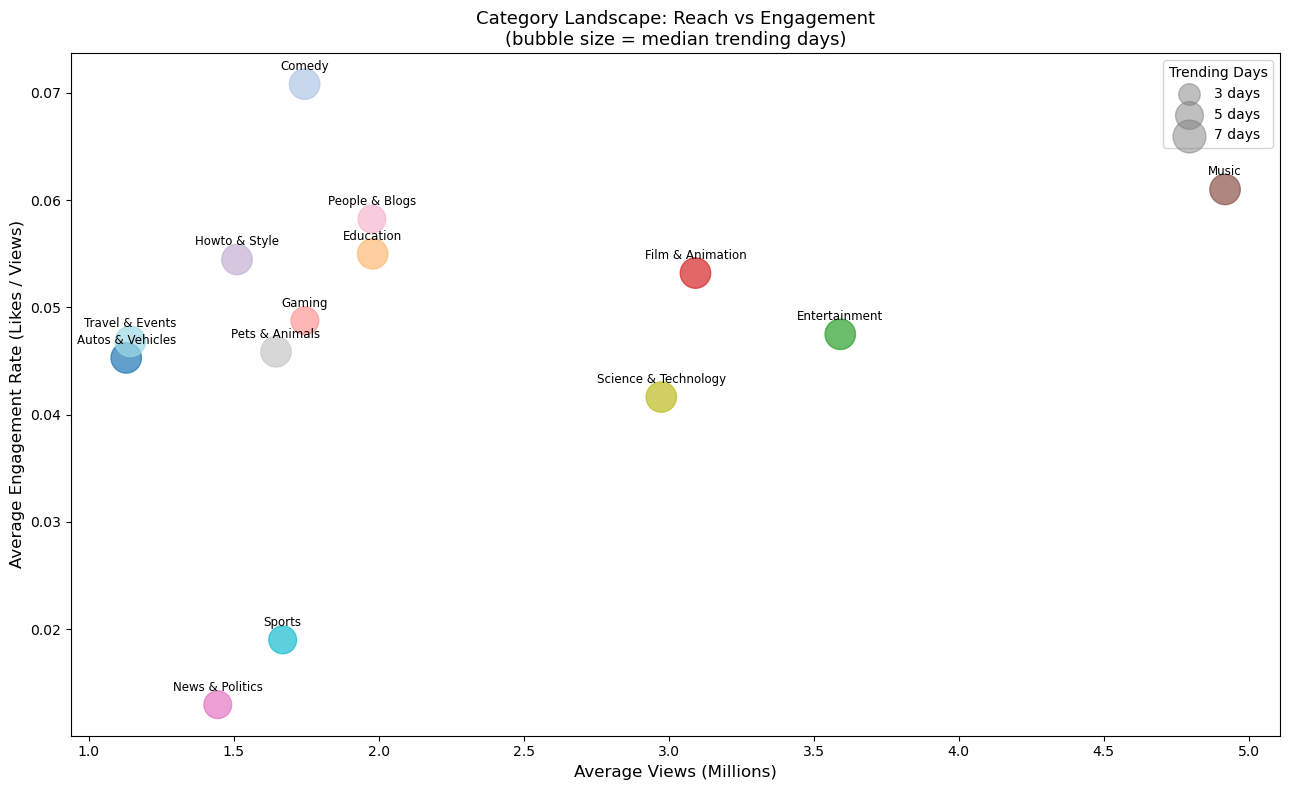

In [27]:
bubble_df = (youtube_df.groupby('category_name')
             .agg(avg_views=('view_count', 'mean'),
                  avg_engagement=('engagement_rate', 'mean'),
                  median_trending_days=('trending_days', 'median'),
                  video_count=('video_id', 'count'))
             .reset_index())

bubble_df = bubble_df[bubble_df['video_count'] >= 100]

fig, ax = plt.subplots(figsize=(13, 8))

scatter = ax.scatter(
    bubble_df['avg_views'] / 1e6,
    bubble_df['avg_engagement'],
    s=bubble_df['median_trending_days'] * 80,
    alpha=0.7,
    c=range(len(bubble_df)),
    cmap='tab20'
)

for _, row in bubble_df.iterrows():
    ax.annotate(row['category_name'],
                xy=(row['avg_views'] / 1e6, row['avg_engagement']),
                fontsize=8.5, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

ax.set_xlabel('Average Views (Millions)', fontsize=12)
ax.set_ylabel('Average Engagement Rate (Likes / Views)', fontsize=12)
ax.set_title('Category Landscape: Reach vs Engagement\n(bubble size = median trending days)', fontsize=13)

sizes = [3, 5, 7]
handles = [plt.scatter([], [], s=d * 80, color='gray', alpha=0.5, label=f'{d} days') for d in sizes]
ax.legend(handles=handles, title='Trending Days', loc='upper right')

plt.tight_layout()
plt.show()

## 6. Key Takeaways

1. **Gaming has volume, Music has reach.** Gaming accounts for the most trending videos (9,434), but Music averages 4.9M views per video — nearly 3x more than Gaming. If the goal is views, category choice matters more than upload frequency.

2. **Comedy gets the most audience interaction.** At 7.1% engagement rate, Comedy outperforms every major category despite having far fewer trending videos. Smaller but more invested audiences respond more actively.

3. **The trending window is short.** The median video stays trending for 6 days. Planning for sustained content output matters more than banking on one video staying visible for long.

4. **Timing helps you get in, content takes you further.** Uploading between 3–5 PM UTC correlates with more trending appearances, but average views per video barely changes across time slots. The signal is there but it's weak.

5. **High views and high engagement are different things.** The engagement rate flattens past a few million views. Viral scale and audience connection don't move together — optimizing for one doesn't guarantee the other.